In [45]:
import torch
from Tokenizers import TokenizersConfig, Tokenizers
from torch.utils.data import Dataset
from torchaudio.transforms import Resample
from torchcodec.decoders import AudioDecoder
from torchaudio.compliance import kaldi
from torchcodec.decoders import AudioDecoder
from IPython.display import Audio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

In [3]:
audio_path = "/Users/leo/projects/orcas/ds/1562337136_0005.wav"
decoder = AudioDecoder(audio_path, sample_rate=16000)
start_time = 3.815
end_time = 6.815
audio_data = decoder.get_samples_played_in_range(start_time, end_time).data
if audio_data.shape[0] > 1:
    audio_data = audio_data[0]
if audio_data.ndim == 1:
    audio_data = audio_data.unsqueeze(0)
padding_mask = torch.zeros_like(audio_data).bool()

In [38]:
checkpoint = torch.load("/Users/leo/projects/orcas/ds/Tokenizer_iter3.pt")
cfg = TokenizersConfig(checkpoint['cfg'])
BEATs_tokenizer = Tokenizers(cfg)
BEATs_tokenizer.load_state_dict(checkpoint['model'])
BEATs_tokenizer.eval()

labels = BEATs_tokenizer.extract_labels(audio_data, padding_mask=padding_mask)

In [39]:
Audio(data=audio_data, rate=16000)

In [70]:
# Prepare the spectrogram data to plot, with the transforms of the BEATs paper

soundwave = audio_data * 2 ** 15       # scale to int16 range    
fbank = kaldi.fbank(soundwave, num_mel_bins=128, sample_frequency=16000, frame_length=25, frame_shift=10)
fbank.shape
#   in labels, every time frame corresponds to 8 consecutive labels
patch_h = 16
patch_w = 16
n_freq= fbank.shape[1]//16

In [95]:
labels_array = np.asarray(labels)
unique = np.unique_counts(labels_array)
print(unique)

UniqueCountsResult(values=array([   0,   21,   31,   56,   64,   65,   70,   73,   82,   89,  118,
        122,  146,  147,  150,  161,  165,  172,  173,  189,  245,  265,
        278,  312,  332,  335,  341,  356,  364,  373,  375,  377,  382,
        392,  403,  410,  430,  433,  434,  438,  440,  446,  472,  473,
        474,  475,  511,  516,  539,  550,  556,  577,  591,  592,  599,
        615,  621,  622,  644,  645,  652,  661,  677,  692,  718,  723,
        742,  748,  755,  756,  767,  769,  784,  792,  794,  797,  808,
        816,  833,  862,  886,  902,  909,  912,  913,  943,  949,  950,
        970,  985,  990,  993,  997,  998, 1001]), counts=array([ 1,  2,  2,  2,  2,  1,  2,  1,  4,  1,  4,  2,  1,  1,  1,  1,  1,
        1,  1,  2,  1,  1,  1,  1,  1,  1,  1,  1,  1,  2,  1,  3,  1,  1,
        1,  1,  1,  1,  1,  1,  5,  2,  1,  1,  2,  1,  2,  3,  1,  1,  1,
        1,  2,  1, 14,  1,  1,  3,  2,  1,  1,  1,  2,  2,  1,  1,  1,  1,
        1,  1,  1,  2,  1,  1,  

In [109]:
# pick a target count

target_count = 2
mask = unique.counts == target_count
codebook_indices = unique.values[mask]
codebook_indices

array([ 21,  31,  56,  64,  70, 122, 189, 373, 446, 474, 511, 591, 644,
       677, 692, 769, 816, 943])

In [110]:
# Choose a list of patches by their index in the array.
patch_index = [i for i, v in enumerate(labels) if v==21]
patch_index

[25, 113]

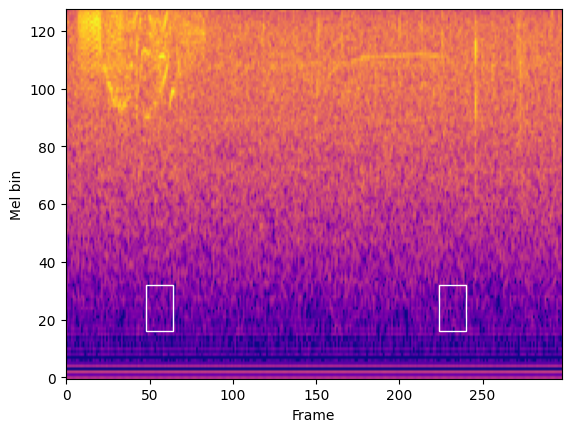

In [111]:
fig, ax = plt.subplots()
ax.imshow(fbank.T.numpy(), origin="lower", aspect="auto", cmap="plasma", vmin=8)
for i in patch_index:
    t = i // n_freq
    f = i % n_freq
    rect=mpatches.Rectangle((t*patch_h, f*patch_w), patch_h, patch_w, linewidth=1, edgecolor="white", facecolor="none")
    ax.add_patch(rect)

ax.set_xlabel("Frame")
ax.set_ylabel("Mel bin")
plt.show()